In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE

# Graph Style
plt.style.use("ggplot")

# Display all columns
pd.set_option("display.max_columns", None)

# Credit Card Fraud Detection using Machine Learning

## Objective

The goal of this project is to detect fraudulent credit card transactions using machine learning while addressing the issue of class imbalance. The project applies data preprocessing, SMOTE oversampling, Logistic Regression, and Random Forest models, followed by evaluation using Precision, Recall, F1-Score, and ROC-AUC.

In [2]:
# Load Dataset

df = pd.read_csv("Dataset/creditcard.csv")

# Display first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Shape of Dataset

print("Shape:", df.shape)

# Dataset Information
df.info()

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V

# Dataset Inspection and Class Imbalance Analysis

This section analyzes the distribution of fraudulent and non-fraudulent transactions to understand the class imbalance present in the dataset.

In [4]:
# Class Distribution

print(df["Class"].value_counts())

# Percentage Distribution

fraud_percentage = (df["Class"].sum() / len(df)) * 100

print(f"\nFraudulent Transactions: {fraud_percentage:.4f}%")
print(f"Non-Fraudulent Transactions: {100 - fraud_percentage:.4f}%")

Class
0    284315
1       492
Name: count, dtype: int64

Fraudulent Transactions: 0.1727%
Non-Fraudulent Transactions: 99.8273%


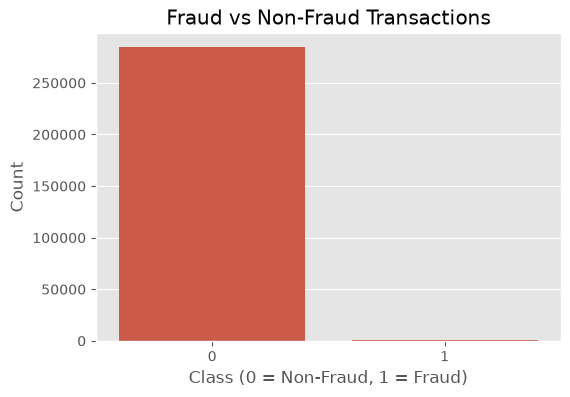

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")

plt.savefig(
    "Images/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

The dataset is highly imbalanced. Non-fraudulent transactions make up the vast majority of the data, while fraudulent transactions represent only a very small percentage.

This imbalance makes fraud detection challenging and requires specialized techniques such as SMOTE or class balancing during model training.

# Transaction Amount Analysis

This section compares the transaction amount distribution between fraudulent and non-fraudulent transactions.

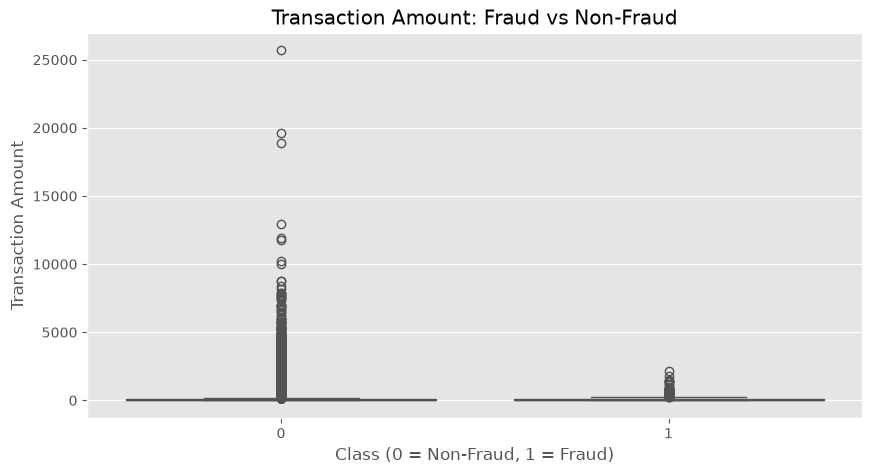

In [6]:
plt.figure(figsize=(10,5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount: Fraud vs Non-Fraud")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.savefig(
    "Images/transaction_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

The boxplot compares transaction amounts for fraudulent and non-fraudulent transactions. It helps identify whether fraudulent transactions generally involve smaller or larger amounts and highlights the presence of outliers.

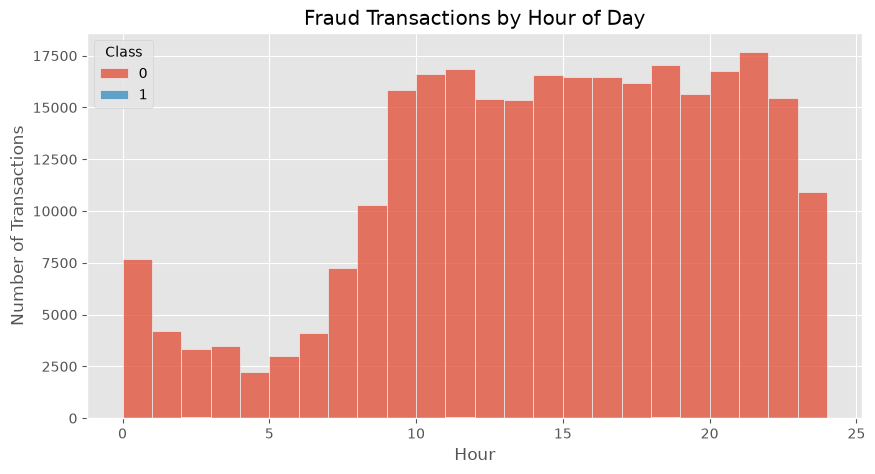

In [7]:
# Convert seconds into hours

df["Hour"] = (df["Time"] / 3600) % 24

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Hour",
    hue="Class",
    bins=24,
    multiple="stack"
)

plt.title("Fraud Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")

plt.savefig(
    "Images/time_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

This visualization shows how fraudulent and non-fraudulent transactions are distributed across different hours of the day. Such patterns can help identify unusual transaction activity during specific time periods.

# Why Accuracy is Misleading

Fraud detection datasets are highly imbalanced because fraudulent transactions are very rare compared to legitimate transactions.

For example, if only 0.17% of transactions are fraudulent, a model that predicts every transaction as non-fraud would still achieve more than 99% accuracy.

Therefore, accuracy alone is not a reliable evaluation metric. Metrics such as Precision, Recall, F1-Score, and ROC-AUC provide a much better understanding of a fraud detection model's performance.

# Train-Test Split

The dataset is divided into training and testing sets using stratified sampling so that both sets contain fraudulent and non-fraudulent transactions in the same proportion.

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (227845, 31)
Testing Samples: (56962, 31)


# Handling Class Imbalance using SMOTE

SMOTE (Synthetic Minority Oversampling Technique) creates synthetic fraud samples to balance the dataset before model training.

In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original Training Distribution")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Original Training Distribution
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE
Class
0    227451
1    227451
Name: count, dtype: int64


# Model 1 - Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=2000,
    solver="liblinear",
    random_state=42
)
lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

# Model 2 - Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# Model Evaluation

In [14]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

print("LOGISTIC REGRESSION\n")

print(classification_report(y_test, y_pred_lr))

print("ROC AUC:", roc_auc_score(y_test,y_prob_lr))

print("\n=========================\n")

print("RANDOM FOREST\n")

print(classification_report(y_test,y_pred_rf))

print("ROC AUC:", roc_auc_score(y_test,y_prob_rf))

LOGISTIC REGRESSION

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.22        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962

ROC AUC: 0.9762150903552191


RANDOM FOREST

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.85      0.85        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9693218980051221


# ROC Curve

The ROC Curve compares the True Positive Rate and False Positive Rate of both models. The Area Under the Curve (AUC) indicates how well the model distinguishes between fraud and non-fraud transactions.

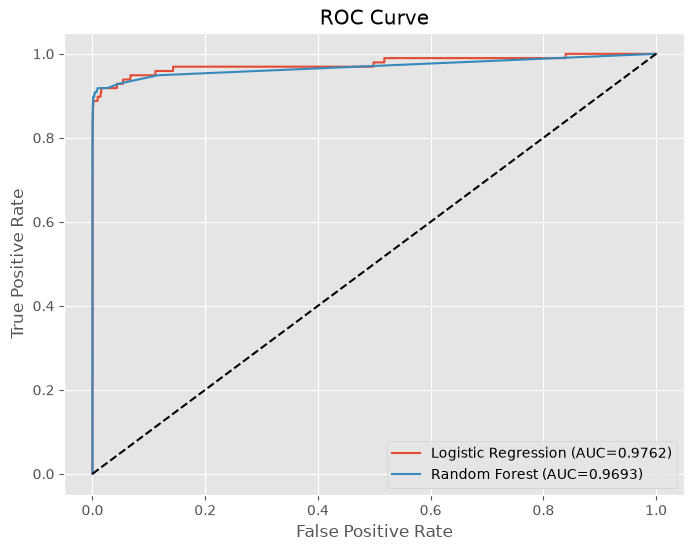

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label=f"Logistic Regression (AUC={roc_auc_score(y_test,y_prob_lr):.4f})")

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC={roc_auc_score(y_test,y_prob_rf):.4f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.savefig(
    "Images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Importance

Random Forest provides feature importance scores that indicate which variables contribute most to fraud prediction.

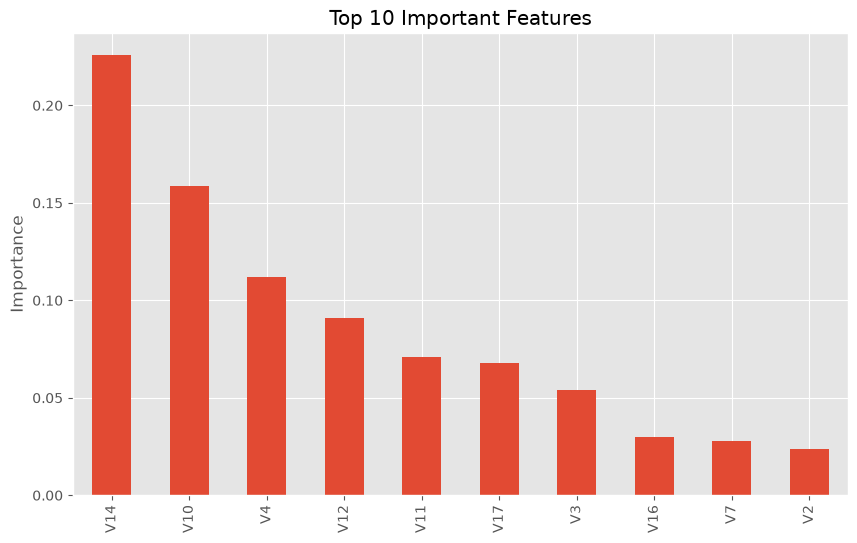

In [16]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features")

plt.ylabel("Importance")

plt.savefig(
    "Images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Recall vs Precision

In fraud detection, Recall is generally more important than Precision.

A high Recall ensures that most fraudulent transactions are detected, even if some legitimate transactions are incorrectly flagged.

Precision is also important because too many false alarms can inconvenience customers.

In real-world fraud detection systems, maintaining high Recall while keeping acceptable Precision is the preferred trade-off.

# Scalability Discussion

To process one million transactions per hour, the fraud detection system should:

- Deploy the trained model as a real-time prediction API.
- Process transactions in parallel using distributed computing.
- Continuously retrain the model with new transaction data.
- Use cloud platforms such as AWS, Azure, or Google Cloud for scalable deployment.
- Monitor model performance and retrain periodically to adapt to new fraud patterns.

Random Forest provides good predictive performance, while Logistic Regression offers faster inference for large-scale deployment.

# Conclusion

This project developed a fraud detection pipeline using machine learning techniques on an imbalanced credit card transaction dataset.

SMOTE was applied to balance the training data, and both Logistic Regression and Random Forest models were trained and evaluated.

Performance was assessed using Precision, Recall, F1-Score, and ROC-AUC rather than relying only on Accuracy.

The project demonstrates how machine learning can effectively identify fraudulent transactions and support financial institutions in reducing fraud-related losses.